#### 6.6 卷积神经网络（LeNet）
此前，使用softmax回归模型和多餐感知机模型应用于Fashion-MNIST数据集，将28×28像素图像展平成为784维的固定长度的一维向量，用全连接层对其进行处理。现在，使用卷积神经网络代替全连接层，可以使模型更简洁，所需的参数更少。
##### 6.6.1 LeNet
LeNet组成：
- **卷积编码器**：由2个卷积层组成；
- **全连接层稠密块**：由3个卷积层组成。

每个卷积块中的基本单元是一个卷积层、一个sigmoid激活函数和平均汇聚层。这些层将输入映射到多个二位特征输出，通常同时增加通道的数量；第一个卷积层由6个输出通道，第二个卷积层有16个输出通道；每个2×2汇聚操作、步幅2通过空间降采样将维数减少4倍，输出形状由批量大小、通道数、高度、宽度决定。
- 网络整体结构：输入→卷积→池化→卷积→池化→展平→全连接→分类；
- 空间信息分辨率降低，语义信息通道数增加；
- 越往后，特征越抽象，需要更多通道表达；
- 越往后，分辨率越来越小，用更少的空间，表达更高级的语义。
- ```Conv2d```：提取特征；
- ```AvePool2d```：压缩信息。

In [1]:
import torch
from torch import nn
net = nn.Sequential(                                # 输入：(1, 28, 28)
    nn.Conv2d(1, 6, kernel_size=5, padding=2),      # 输出：(6, 28, 28)
    nn.AvgPool2d(kernel_size=2, stride=2),          # 输出：(6, 14, 14)
    nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),     # 输出：(16, 10, 10)
    nn.AvgPool2d(kernel_size=2, stride=2),          # 输出：(16, 5, 5)
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.ReLU(),          # 输入：16×5×5=400
    nn.Linear(120, 84), nn.ReLU(),
    nn.Linear(84, 10)
)
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
ReLU output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
ReLU output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
ReLU output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


##### 6.6.2 模型训练
卷积神经网络的参数较少，但每个参数都参与更多的乘法，通过使用GPU可以加快训练。

In [2]:
# 加载Fashion-MNIST数据集
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='D:/Algorithm_and_Deep_Learning/DeepLearningNotes/data', train=True, download=False, transform=transform)
test_dataset = datasets.FashionMNIST('D:/Algorithm_and_Deep_Learning/DeepLearningNotes/data', train=False, download=False, transform=transform)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
train_iter, test_iter = train_loader, test_loader
print(len(train_dataset), len(test_dataset))

60000 10000


In [3]:
# GPU版训练
import sys, os
sys.path.append(os.path.abspath('../..'))
from DeepLearningNotes.Functions import *

def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    # 正确预测的数量，总预测的数量
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [4]:
#@save
history = {'train_loss':[], 'train_acc':[], 'test_acc':[]}
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """使用GPU训练"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            global test_acc
            global train_l
            global train_acc
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                            (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
        history['train_loss'].append(train_l)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)


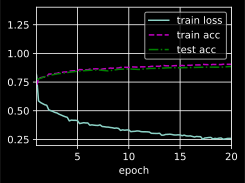

In [8]:
lr, num_epochs = 0.001, 20
train_ch6(net, train_iter, test_iter, num_epochs, lr, torch.device('cuda:0'))

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['train_acc'], label='train acc')
plt.plot(history['test_acc'], label='test acc')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.title(f'LeNet | lr={lr}, epochs={num_epochs}')
plt.tight_layout()
plt.savefig('training_curve_ReLU.svg')  # 保存到文件，不依赖弹窗
plt.show()

In [7]:
print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
      f'test acc {test_acc:.3f}')

loss 0.304, train acc 0.889, test acc 0.875


**优化器的选择**
- SGD：固定lr，对lr敏感度高；
- Adam：自适应调整lr。